In [ ]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import seaborn as sn

In [ ]:
dataset = pd.read_csv('boston_r.csv')
with pd.option_context('display.max_rows', 6): display(dataset)
dataset.columns

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')

             crim        zn     indus      chas       nox        rm       age  \
crim     1.000000 -0.200469  0.406583 -0.055892  0.420972 -0.219247  0.352734   
zn      -0.200469  1.000000 -0.533828 -0.042697 -0.516604  0.311991 -0.569537   
indus    0.406583 -0.533828  1.000000  0.062938  0.763651 -0.391676  0.644779   
chas    -0.055892 -0.042697  0.062938  1.000000  0.091203  0.091251  0.086518   
nox      0.420972 -0.516604  0.763651  0.091203  1.000000 -0.302188  0.731470   
rm      -0.219247  0.311991 -0.391676  0.091251 -0.302188  1.000000 -0.240265   
age      0.352734 -0.569537  0.644779  0.086518  0.731470 -0.240265  1.000000   
dis     -0.379670  0.664408 -0.708027 -0.099176 -0.769230  0.205246 -0.747881   
rad      0.625505 -0.311948  0.595129 -0.007368  0.611441 -0.209847  0.456022   
tax      0.582764 -0.314563  0.720760 -0.035587  0.668023 -0.292048  0.506456   
ptratio  0.289946 -0.391679  0.383248 -0.121515  0.188933 -0.355501  0.261515   
black   -0.385064  0.175520 

<Axes: >

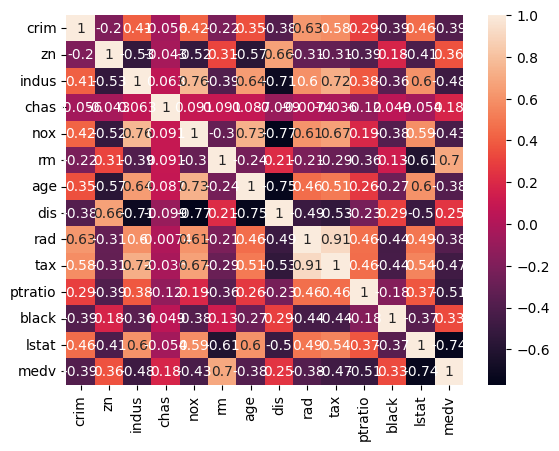

In [ ]:
corr_matrix = dataset.corr()
print(corr_matrix)

sn.heatmap(corr_matrix, annot=True)

In [ ]:
# Training Set
x = dataset[['lstat','rm']]
x1 = dataset['lstat']
x2 = dataset['rm']
y = dataset['medv']
x.head

<bound method NDFrame.head of      lstat     rm
0     4.98  6.575
1     9.14  6.421
2     4.03  7.185
3     2.94  6.998
4     5.33  7.147
..     ...    ...
501   9.67  6.593
502   9.08  6.120
503   5.64  6.976
504   6.48  6.794
505   7.88  6.030

[506 rows x 2 columns]>

In [ ]:
print(x)

     lstat     rm
0     4.98  6.575
1     9.14  6.421
2     4.03  7.185
3     2.94  6.998
4     5.33  7.147
..     ...    ...
501   9.67  6.593
502   9.08  6.120
503   5.64  6.976
504   6.48  6.794
505   7.88  6.030

[506 rows x 2 columns]


# Split dataset

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1)

print(x_train)

     lstat     rm
42    5.81  6.169
58    6.86  6.145
385  30.81  5.277
78   12.34  6.232
424  17.16  5.565
..     ...    ...
255   9.25  5.876
72    5.52  6.065
396  19.37  6.405
235  10.88  6.086
37    8.77  5.850

[404 rows x 2 columns]


In [ ]:
print(x_train)

     lstat     rm
42    5.81  6.169
58    6.86  6.145
385  30.81  5.277
78   12.34  6.232
424  17.16  5.565
..     ...    ...
255   9.25  5.876
72    5.52  6.065
396  19.37  6.405
235  10.88  6.086
37    8.77  5.850

[404 rows x 2 columns]


In [ ]:
print(x_test)

     lstat     rm
307   7.53  6.849
343   7.18  6.696
47   18.80  6.030
67    8.10  5.878
362  10.19  5.362
..     ...    ...
92    8.16  6.442
224   4.14  8.266
110  13.00  6.195
426  15.69  5.837
443  18.85  6.485

[102 rows x 2 columns]


In [ ]:
print(y_train)

42     25.3
58     23.3
385     7.2
78     21.2
424    11.7
       ... 
255    20.9
72     22.8
396    12.5
235    24.0
37     21.0
Name: medv, Length: 404, dtype: float64


In [ ]:
print(y_test)

307    28.2
343    23.9
47     16.6
67     22.0
362    20.8
       ... 
92     22.9
224    44.8
110    21.7
426    10.2
443    15.4
Name: medv, Length: 102, dtype: float64


# **Feature Scaling on Training Set & Test Set**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

scaler = StandardScaler().fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

# **Training the Multiple Linear Regression model**

In [ ]:
model = LinearRegression()
model.fit(x_train_scaled,y_train)
print(model.coef_)
print(model.intercept_)
print("")
print("Features :", x_train.columns.tolist())
print("Coefficient :", model.coef_)
print("Intercept :", model.intercept_)

[-4.75193957  3.12451365]
22.52227722772278

Features : ['lstat', 'rm']
Coefficient : [-4.75193957  3.12451365]
Intercept : 22.52227722772278


c. Write the regression equation.     

From Estimate Multiple Regression Equation      
y = b0 + b1x1 + b2x2 + b3x3 + ...       
Given B0 is Intercept, B1 and go on is coefficients, and X1 and go on is a Variable or in this called features.

**Answer is 22.522 + (-4.752 * lstat) + (3.12 * rm)**

# **RMSE evaluation (Root Mean Squared Error)**

In [ ]:
y_pred = model.predict(x_test_scaled)
rmse = mean_squared_error(y_test,y_pred, squared=False)
print("RMSE = ", rmse)

RMSE =  5.664252472426871
